[*********************100%***********************]  1 of 1 completed

Strategy total return: 1.185534, Excess return vs buy & hold: 0.114515
    side entry_date  entry_price  exit_date  exit_price  exit_reason  pnl_pct
0   long 2026-01-20   177.853073 2026-01-22  184.614822  take_profit   0.0380
1   long 2026-02-04   173.977798 2026-02-06  185.184128  take_profit   0.0644
2   long 2026-02-27   176.974152 2026-03-10  184.544922  take_profit   0.0428
3   long 2026-03-20   172.498947 2026-03-27  167.324982   trail_stop  -0.0300
4  short 2026-04-14   196.281235 2026-04-24  208.027542   trail_stop  -0.0565
5  short 2026-04-27   216.357834 2026-04-30  199.337677  take_profit   0.0854
6   long 2026-06-05   205.100006 2026-06-15  212.449997  take_profit   0.0358


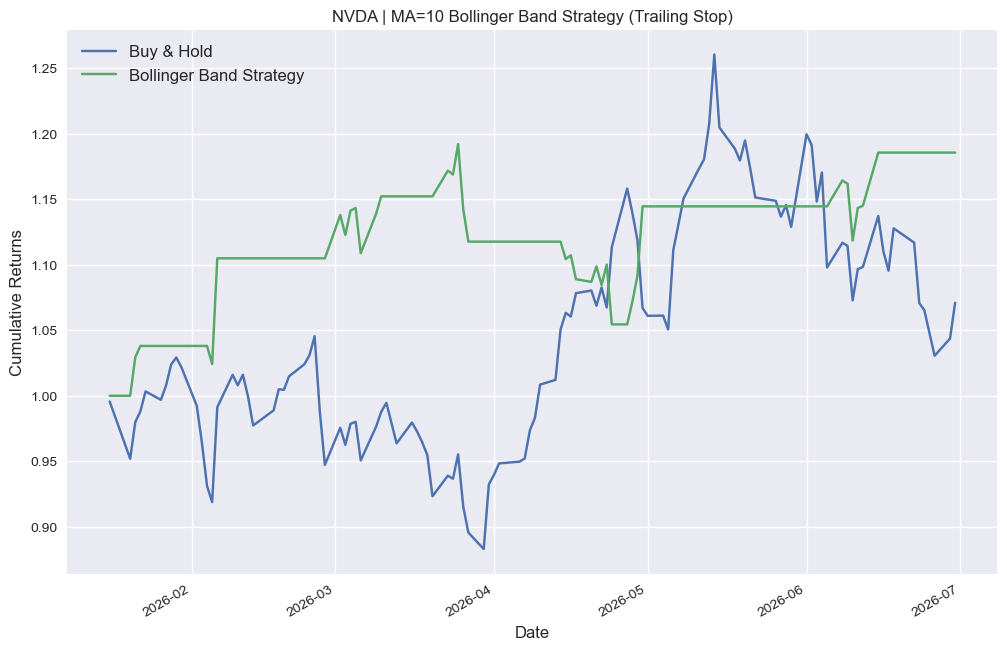

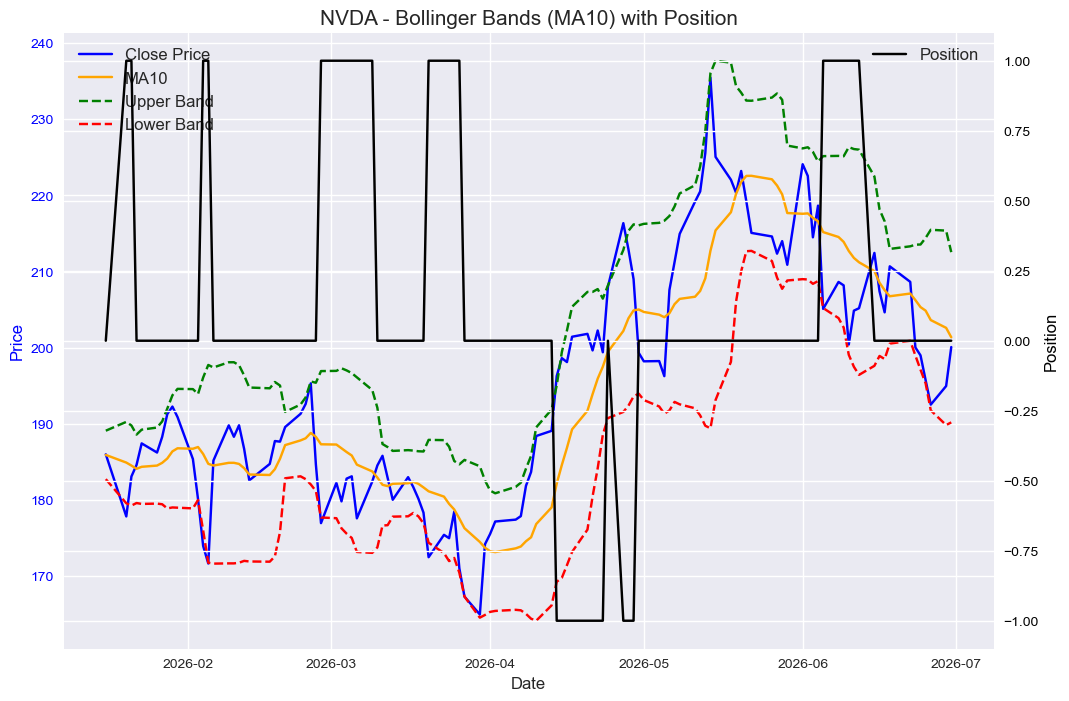

In [18]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt


class BollingerBandTrailingBacktester:
    """
    Backtester for a Bollinger Band mean-reversion strategy with a trailing
    stop plus a hard stop.

    Entry logic:
      - Price drops below the lower band -> go long
      - Price rises above the upper band -> go short

    Exit logic (checked in this order, first match wins):
      1. Hard stop (exit_threshold): price moves further past the band,
         beyond the band by this extra margin
      2. Trailing stop (trail_percentage): price pulls back from the
         highest/lowest price reached during the trade
      3. Take profit: price returns to the middle band (MA)
    """

    def __init__(self, symbol, MA, start, end, std_dev=2.0,
                 exit_threshold=0.02, trail_percentage=0.05):
        self.symbol = symbol
        self.MA = MA
        self.start = start
        self.end = end
        self.std_dev = std_dev
        self.exit_threshold = exit_threshold
        self.trail_percentage = trail_percentage

        self.data = None      # raw price data + Bollinger Band indicators
        self.results = None   # full results after test_results()
        self.trades = None    # per-trade log

        self.get_data()

    # ------------------------------------------------------------------
    # Data processing
    # ------------------------------------------------------------------
    def get_data(self):
        """Download price data and compute Bollinger Band related columns"""
        df = yf.download(self.symbol, start=self.start, end=self.end, auto_adjust=True)
        if df.empty:
            raise ValueError(f"No data retrieved for {self.symbol} from {self.start} to {self.end}")

        close = self._extract_close(df)

        data = pd.DataFrame(index=close.index)
        data["Close"] = close
        data["returns"] = np.log(data["Close"] / data["Close"].shift(1))
        data["MA"] = data["Close"].rolling(self.MA).mean()
        data["std"] = data["Close"].rolling(self.MA).std()
        data["upper_band"] = data["MA"] + self.std_dev * data["std"]
        data["lower_band"] = data["MA"] - self.std_dev * data["std"]

        # Hard stop lines: pushed further past the band, in the unfavorable direction
        data["upper_stop"] = data["upper_band"] * (1 + self.exit_threshold)  # hard stop for shorts
        data["lower_stop"] = data["lower_band"] * (1 - self.exit_threshold)  # hard stop for longs

        data.dropna(inplace=True)
        if data.empty:
            raise ValueError("No valid data after processing. Check MA period or data availability.")

        self.data = data
        return data

    @staticmethod
    def _extract_close(df):
        """Handle both single-level and MultiIndex yfinance columns, return a single Close Series"""
        if isinstance(df.columns, pd.MultiIndex):
            for col in df.columns:
                if col[0] == "Close":
                    return df[col]
            raise ValueError(f"No 'Close' column found in multi-index DataFrame: {df.columns}")
        if "Close" not in df.columns:
            raise ValueError(f"No 'Close' column found in DataFrame: {df.columns}")
        return df["Close"]

    # ------------------------------------------------------------------
    # Core strategy logic
    # ------------------------------------------------------------------
    def test_results(self):
        """Run the strategy simulation, return (total strategy return, excess return vs buy & hold)"""
        data = self.data.copy()
        data["position"] = 0

        position = 0
        entry_price = 0.0
        entry_date = None
        extreme_price = 0.0  # highest price while long, lowest price while short
        trades = []

        for i in range(1, len(data)):
            price = float(data["Close"].iat[i])
            ma = float(data["MA"].iat[i])
            upper_band = float(data["upper_band"].iat[i])
            lower_band = float(data["lower_band"].iat[i])
            upper_stop = float(data["upper_stop"].iat[i])
            lower_stop = float(data["lower_stop"].iat[i])
            date = data.index[i]

            if position == 1:
                extreme_price = max(extreme_price, price)
                trail_stop = extreme_price * (1 - self.trail_percentage)
                exit_now, reason = self._check_long_exit(price, ma, trail_stop, lower_stop)
                if exit_now:
                    trades.append(self._make_trade("long", entry_date, entry_price, date, price, reason))
                    position, entry_price, extreme_price = 0, 0.0, 0.0

            elif position == -1:
                extreme_price = min(extreme_price, price) if extreme_price else price
                trail_stop = extreme_price * (1 + self.trail_percentage)
                exit_now, reason = self._check_short_exit(price, ma, trail_stop, upper_stop)
                if exit_now:
                    trades.append(self._make_trade("short", entry_date, entry_price, date, price, reason))
                    position, entry_price, extreme_price = 0, 0.0, 0.0

            else:
                if price <= lower_band:
                    position, entry_price, extreme_price, entry_date = 1, price, price, date
                elif price >= upper_band:
                    position, entry_price, extreme_price, entry_date = -1, price, price, date

            data.iat[i, data.columns.get_loc("position")] = position

        # Compute strategy returns (position lagged by one bar to avoid lookahead bias)
        data["strategy"] = data["returns"] * data["position"].shift(1)
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)          # buy & hold return
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)   # strategy return

        perf = data["returnsstrategy"].iloc[-1]        # total strategy return
        outperf = perf - data["returnsbh"].iloc[-1]     # excess return vs buy & hold

        self.results = data
        self.trades = pd.DataFrame(trades)
        return round(perf, 6), round(outperf, 6)

    @staticmethod
    def _check_long_exit(price, ma, trail_stop, hard_stop):
        if price <= hard_stop:
            return True, "hard_stop"
        if price <= trail_stop:
            return True, "trail_stop"
        if price >= ma:
            return True, "take_profit"
        return False, None

    @staticmethod
    def _check_short_exit(price, ma, trail_stop, hard_stop):
        if price >= hard_stop:
            return True, "hard_stop"
        if price >= trail_stop:
            return True, "trail_stop"
        if price <= ma:
            return True, "take_profit"
        return False, None

    @staticmethod
    def _make_trade(side, entry_date, entry_price, exit_date, exit_price, reason):
        pnl_pct = (exit_price / entry_price - 1) if side == "long" else (entry_price / exit_price - 1)
        return {
            "side": side,
            "entry_date": entry_date,
            "entry_price": entry_price,
            "exit_date": exit_date,
            "exit_price": exit_price,
            "exit_reason": reason,
            "pnl_pct": round(pnl_pct, 4),
        }

    # ------------------------------------------------------------------
    # Plotting
    # ------------------------------------------------------------------
    def plot_results(self):
        """Plot cumulative return curve"""
        if self.results is None:
            print("Please run test_results() first")
            return
        plt.style.use("seaborn-v0_8")
        title = f"{self.symbol} | MA={self.MA} Bollinger Band Strategy (Trailing Stop)"
        self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
        plt.legend(["Buy & Hold", "Bollinger Band Strategy"], loc="upper left", fontsize=12)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Cumulative Returns", fontsize=12)
        plt.show()

    def plot_bollinger_bands(self):
        """Plot Bollinger Bands and price"""
        data = self.data
        plt.style.use("seaborn-v0_8")
        plt.figure(figsize=(12, 8))
        plt.plot(data["Close"], label="Close Price", color="blue")
        plt.plot(data["MA"], label=f"MA{self.MA}", color="orange")
        plt.plot(data["upper_band"], label="Upper Band", color="green", linestyle="--")
        plt.plot(data["lower_band"], label="Lower Band", color="red", linestyle="--")
        plt.plot(data["upper_stop"], label="Upper Hard Stop", color="purple", linestyle=":")
        plt.plot(data["lower_stop"], label="Lower Hard Stop", color="brown", linestyle=":")
        plt.legend(loc="upper left", fontsize=12)
        plt.title(f"{self.symbol} Price with Bollinger Bands (MA{self.MA})", fontsize=15)
        plt.xlabel("Date", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.show()

    def plot_bollinger_with_position(self, year=None):
        """Plot Bollinger Bands together with position state"""
        if self.results is None:
            print("Please run test_results() first")
            return
        data = self.results.copy()
        if year:
            data = data.loc[str(year)]

        plt.style.use("seaborn-v0_8")
        fig, ax1 = plt.subplots(figsize=(12, 8))
        ax1.plot(data.index, data["Close"], label="Close Price", color="blue")
        ax1.plot(data.index, data["MA"], label=f"MA{self.MA}", color="orange")
        ax1.plot(data.index, data["upper_band"], label="Upper Band", color="green", linestyle="--")
        ax1.plot(data.index, data["lower_band"], label="Lower Band", color="red", linestyle="--")
        ax1.set_xlabel("Date", fontsize=12)
        ax1.set_ylabel("Price", fontsize=12, color="blue")
        ax1.tick_params(axis="y", labelcolor="blue")
        ax1.legend(loc="upper left", fontsize=12)

        ax2 = ax1.twinx()
        ax2.plot(data.index, data["position"], label="Position", color="black")
        ax2.set_ylabel("Position", fontsize=12, color="black")
        ax2.tick_params(axis="y", labelcolor="black")
        ax2.legend(loc="upper right", fontsize=12)

        plt.title(f"{self.symbol} - Bollinger Bands (MA{self.MA}) with Position", fontsize=15)
        plt.show()


if __name__ == "__main__":
    bt = BollingerBandTrailingBacktester(
        symbol="NVDA", MA=10, start="2026-01-01", end="2026-07-01"
    )
    perf, outperf = bt.test_results()
    print(f"Strategy total return: {perf}, Excess return vs buy & hold: {outperf}")
    print(bt.trades)  # per-trade log, useful for checking whether entries/exits look right
    bt.plot_results()
    bt.plot_bollinger_with_position()